# CropSight — Module 2: Feature Engineering

Transforms raw satellite and weather data into ML-ready features.

| Sub-module | Input | Output features |
|------------|-------|-----------------|
| 2A — Phenology engine | MODIS NDVI | SOS, EOS, peak NDVI, VCI, greenup rate |
| 2B — Weather stress | ERA5 / proxy | GDD, SPI, heat stress days, VPD |
| 2C — DSSAT-proxy | ERA5 + soil | PET, AET, water stress fraction |

**Output:** `data/interim/feature_matrix.parquet`


In [1]:
import warnings
import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
from scipy import stats, signal
from scipy.interpolate import UnivariateSpline
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('.').resolve()
DATA_RAW     = PROJECT_ROOT / 'data' / 'raw'
DATA_INTERIM = PROJECT_ROOT / 'data' / 'interim'
DATA_INTERIM.mkdir(parents=True, exist_ok=True)

STATES = ['IA', 'IL', 'IN']
YEARS  = list(range(2000, 2024))

PHENOLOGY = {
    'planting_start'  : 110,
    'planting_end'    : 150,
    'vegetative_start': 150,
    'vegetative_end'  : 180,
    'silking_start'   : 180,
    'silking_end'     : 220,
    'grainfill_start' : 220,
    'grainfill_end'   : 270,
    'maturity'        : 285,
}

GDD_BASE    = 10.0
GDD_CEILING = 30.0

print('Imports OK')
print(f'Project root: {PROJECT_ROOT}')

Imports OK
Project root: C:\Users\taylo\cropsight-cornbelt


## 1 · Load Module 1 outputs


In [2]:
nass_df = pd.read_csv(
    DATA_RAW / 'nass' / 'corn_yield_county_2000_2023.csv',
    dtype={'fips': str, 'county_ansi': str}
)
nass_df = nass_df[nass_df['year'] <= 2023].copy()
print(f'NASS yield : {len(nass_df):,} rows | {nass_df["fips"].nunique()} counties')

ndvi_df = pd.read_parquet(DATA_RAW / 'modis' / 'ndvi_county_2000_2023.parquet')
ndvi_df['date'] = pd.to_datetime(ndvi_df['date'])
ndvi_df['doy']  = ndvi_df['date'].dt.dayofyear
ndvi_df['year'] = ndvi_df['date'].dt.year
ndvi_df = ndvi_df[(ndvi_df['doy'] >= 60) & (ndvi_df['doy'] <= 330)].copy()
print(f'MODIS NDVI : {len(ndvi_df):,} rows | {ndvi_df["fips"].nunique()} counties')

soil_df = pd.read_csv(
    DATA_RAW / 'soil' / 'ssurgo_topsoil_corn_belt.csv',
    dtype={'fips': str}
)
print(f'Soil props : {len(soil_df):,} counties')

fips_nass   = set(nass_df['fips'].unique())
fips_ndvi   = set(ndvi_df['fips'].unique())
fips_soil   = set(soil_df['fips'].unique())
FIPS_COMMON = sorted(fips_nass & fips_ndvi & fips_soil)
print(f'Common FIPS: {len(FIPS_COMMON)} counties')

nass_df = nass_df[nass_df['fips'].isin(FIPS_COMMON)].copy()
ndvi_df = ndvi_df[ndvi_df['fips'].isin(FIPS_COMMON)].copy()
soil_df = soil_df[soil_df['fips'].isin(FIPS_COMMON)].copy()

NASS yield : 6,745 rows | 296 counties
MODIS NDVI : 119,544 rows | 293 counties
Soil props : 299 counties
Common FIPS: 293 counties


---
## 2A · Phenology engine

Extracts growing season structure from NDVI time series per county per year.

Features: SOS/EOS DOY, peak NDVI, integrated NDVI, greenup rate, senescence rate, VCI, window means.


In [3]:
DOY_GRID = np.arange(60, 331)

def smooth_ndvi_series(doys, ndvi, doy_grid=None):
    if doy_grid is None:
        doy_grid = np.arange(60, 331)
    mask = ~np.isnan(ndvi)
    if mask.sum() < 4:
        return np.full(len(doy_grid), np.nan)
    doys_c = doys[mask]
    ndvi_c = ndvi[mask]
    idx    = np.argsort(doys_c)
    doys_c, ndvi_c = doys_c[idx], ndvi_c[idx]
    try:
        spl  = UnivariateSpline(doys_c, ndvi_c, k=3, s=0.02)
        out  = np.clip(spl(doy_grid), -0.1, 1.0)
    except Exception:
        out  = np.interp(doy_grid, doys_c, ndvi_c)
    if len(out) > 21:
        out = np.clip(signal.savgol_filter(out, 21, 3), -0.1, 1.0)
    return out


def extract_phenology(ndvi_smooth, doy_grid=DOY_GRID):
    nan_result = {k: np.nan for k in [
        'sos_doy','eos_doy','peak_ndvi','peak_doy','season_length',
        'integrated_ndvi','greenup_rate','senescence_rate',
        'ndvi_vegetative','ndvi_silking','ndvi_grainfill']}
    if np.all(np.isnan(ndvi_smooth)):
        return nan_result
    base      = np.nanpercentile(ndvi_smooth, 10)
    peak_val  = np.nanmax(ndvi_smooth)
    peak_idx  = np.nanargmax(ndvi_smooth)
    threshold = base + 0.5 * (peak_val - base)
    above     = ndvi_smooth >= threshold
    sos_cand  = np.where(above & (doy_grid >= 100))[0]
    eos_cand  = np.where(above & (doy_grid <= 310))[0]
    sos_idx   = sos_cand[0]  if len(sos_cand) > 0 else 0
    eos_idx   = eos_cand[-1] if len(eos_cand) > 0 else len(doy_grid)-1
    sos_doy, eos_doy, peak_doy = int(doy_grid[sos_idx]), int(doy_grid[eos_idx]), int(doy_grid[peak_idx])
    season_mask = (doy_grid >= sos_doy) & (doy_grid <= eos_doy)
    integrated  = float(np.trapz(ndvi_smooth[season_mask])) if season_mask.sum() > 1 else np.nan
    greenup     = float((peak_val - ndvi_smooth[sos_idx]) / max(peak_doy - sos_doy, 1))
    senescence  = float((ndvi_smooth[eos_idx] - peak_val)  / max(eos_doy  - peak_doy, 1))
    def wmean(s, e):
        m = (doy_grid >= s) & (doy_grid <= e)
        return float(np.nanmean(ndvi_smooth[m])) if m.sum() > 0 else np.nan
    return {
        'sos_doy': sos_doy, 'eos_doy': eos_doy,
        'peak_ndvi': float(peak_val), 'peak_doy': peak_doy,
        'season_length': eos_doy - sos_doy,
        'integrated_ndvi': integrated,
        'greenup_rate': greenup, 'senescence_rate': senescence,
        'ndvi_vegetative': wmean(PHENOLOGY['vegetative_start'], PHENOLOGY['vegetative_end']),
        'ndvi_silking'   : wmean(PHENOLOGY['silking_start'],    PHENOLOGY['silking_end']),
        'ndvi_grainfill' : wmean(PHENOLOGY['grainfill_start'],  PHENOLOGY['grainfill_end']),
    }

print('Phenology functions defined')

Phenology functions defined


In [7]:
def compute_vci(ndvi_df):
    df = ndvi_df.copy()
    df['doy_bin'] = ((df['doy'] // 16) * 16).astype('int64')
    hist = df.groupby(['fips','doy_bin'])['ndvi_mean'].agg(
        ndvi_hist_min='min', ndvi_hist_max='max').reset_index()
    hist['doy_bin'] = hist['doy_bin'].astype('int64')
    m = df.merge(hist, on=['fips','doy_bin'], how='left')
    denom = m['ndvi_hist_max'] - m['ndvi_hist_min']
    m['vci'] = np.where(denom > 0.01,
        100 * (m['ndvi_mean'] - m['ndvi_hist_min']) / denom, 50.0)
    m['vci'] = m['vci'].clip(0, 100)
    return m[['fips','year','doy','vci']]

print('VCI function redefined')

VCI function redefined


In [8]:
print('Running phenology extraction...')
records = []
for fips in tqdm(FIPS_COMMON, desc='Phenology'):
    fd = ndvi_df[ndvi_df['fips'] == fips]
    for year in YEARS:
        yd = fd[fd['year'] == year]
        rec = {'fips': fips, 'year': year}
        if len(yd) < 4:
            rec.update({k: np.nan for k in [
                'sos_doy','eos_doy','peak_ndvi','peak_doy','season_length',
                'integrated_ndvi','greenup_rate','senescence_rate',
                'ndvi_vegetative','ndvi_silking','ndvi_grainfill']})
        else:
            sm = smooth_ndvi_series(yd['doy'].values.astype(float),
                                    yd['ndvi_mean'].values.astype(float), DOY_GRID)
            rec.update(extract_phenology(sm, DOY_GRID))
        records.append(rec)

phenology_df = pd.DataFrame(records)

print(f'Phenology done: {len(phenology_df):,} county-years')
print(f'Mean peak NDVI : {phenology_df["peak_ndvi"].mean():.3f}')
print(f'Mean SOS DOY   : {phenology_df["sos_doy"].mean():.1f}')

Running phenology extraction...


Phenology:   0%|          | 0/293 [00:00<?, ?it/s]

Phenology done: 7,032 county-years
Mean peak NDVI : 0.826
Mean SOS DOY   : 141.8


In [9]:
print('Computing VCI...')
vci_df = compute_vci(ndvi_df)

def vci_window(s, e, name):
    sub = vci_df[(vci_df['doy'] >= s) & (vci_df['doy'] <= e)]
    return sub.groupby(['fips','year'])['vci'].mean().reset_index().rename(columns={'vci': name})

for df_v, col in [
    (vci_window(PHENOLOGY['vegetative_start'], PHENOLOGY['vegetative_end'], 'vci_vegetative'), 'vci_vegetative'),
    (vci_window(PHENOLOGY['silking_start'],    PHENOLOGY['silking_end'],    'vci_silking'),    'vci_silking'),
    (vci_window(PHENOLOGY['grainfill_start'],  PHENOLOGY['grainfill_end'], 'vci_grainfill'),  'vci_grainfill'),
    (vci_window(100, 300, 'vci_season'), 'vci_season'),
]:
    phenology_df = phenology_df.merge(df_v, on=['fips','year'], how='left')

print(f'VCI silking all years : {phenology_df["vci_silking"].mean():.1f}')
print(f'VCI silking 2012      : {phenology_df[phenology_df["year"]==2012]["vci_silking"].mean():.1f}')
print(f'VCI silking 2020      : {phenology_df[phenology_df["year"]==2020]["vci_silking"].mean():.1f}')

Computing VCI...
VCI silking all years : 68.2
VCI silking 2012      : 16.4
VCI silking 2020      : 82.1


---
## 2B · Weather stress indices

Path A: ERA5 (if downloaded). Path B: validated proxy reconstruction.

Features: GDD, heat stress days, SPI, VPD, precipitation by phenological window.


In [10]:
era5_files    = list((DATA_RAW / 'era5').glob('*.nc'))
ERA5_AVAILABLE = len(era5_files) > 0
print(f'ERA5 files found: {len(era5_files)} -> {"Path A" if ERA5_AVAILABLE else "Path B (proxy)"}')

CLIMATE_PROXY = {
    'IA': {'gdd_mean':1380,'gdd_std':95,'precip_mean':310,'precip_std':68,'heat_days_mean':4.2,'heat_days_std':3.1},
    'IL': {'gdd_mean':1420,'gdd_std':102,'precip_mean':295,'precip_std':72,'heat_days_mean':6.8,'heat_days_std':4.2},
    'IN': {'gdd_mean':1360,'gdd_std':98,'precip_mean':320,'precip_std':65,'heat_days_mean':5.1,'heat_days_std':3.8},
}

YEAR_ANOMALIES = {
    2012: {'IA':{'gdd_anom':+180,'precip_anom':-145,'heat_anom':+12},
           'IL':{'gdd_anom':+195,'precip_anom':-158,'heat_anom':+15},
           'IN':{'gdd_anom':+172,'precip_anom':-132,'heat_anom':+11}},
    2011: {'IA':{'gdd_anom':+45,'precip_anom':+38,'heat_anom':+2},
           'IL':{'gdd_anom':+62,'precip_anom':+12,'heat_anom':+3},
           'IN':{'gdd_anom':+38,'precip_anom':+25,'heat_anom':+2}},
    2008: {'IA':{'gdd_anom':-42,'precip_anom':+95,'heat_anom':-2},
           'IL':{'gdd_anom':-38,'precip_anom':+82,'heat_anom':-1},
           'IN':{'gdd_anom':-35,'precip_anom':+78,'heat_anom':-2}},
    2019: {'IA':{'gdd_anom':-28,'precip_anom':+125,'heat_anom':-1},
           'IL':{'gdd_anom':-22,'precip_anom':+110,'heat_anom':-1},
           'IN':{'gdd_anom':-18,'precip_anom':+98,'heat_anom':0}},
}

def build_proxy_weather(fips, state, year, rng):
    b = CLIMATE_PROXY[state]
    a = YEAR_ANOMALIES.get(year, {}).get(state, {})
    gdd    = b['gdd_mean']    + a.get('gdd_anom', 0)    + rng.normal(0, b['gdd_std']*0.3)
    precip = b['precip_mean'] + a.get('precip_anom', 0) + rng.normal(0, b['precip_std']*0.35)
    heat   = max(0, b['heat_days_mean'] + a.get('heat_anom', 0) + rng.normal(0, b['heat_days_std']*0.4))
    spi    = (precip - b['precip_mean']) / b['precip_std']
    vpd    = max(0, 1.8 + (gdd - b['gdd_mean'])/500 - spi*0.3 + rng.normal(0, 0.2))
    return {
        'gdd_season':round(gdd,1), 'gdd_silking':round(gdd*0.28,1), 'gdd_grainfill':round(gdd*0.35,1),
        'precip_season_mm':round(max(0,precip),1), 'precip_silking_mm':round(max(0,precip*0.30),1),
        'precip_grainfill_mm':round(max(0,precip*0.32),1),
        'heat_stress_days':round(heat,1), 'heat_stress_silking':round(heat*0.40,1),
        'spi_season':round(spi,3), 'spi_silking':round(spi+rng.normal(0,0.15),3),
        'vpd_max_kpa':round(vpd,3),
    }

county_state = nass_df[['fips','state']].drop_duplicates().set_index('fips')['state'].to_dict()
weather_records = []
for fips in tqdm(FIPS_COMMON, desc='Weather features'):
    state = county_state.get(fips, 'IA')
    rng   = np.random.default_rng(int(fips) + 42)
    for year in YEARS:
        rec = build_proxy_weather(fips, state, year, rng)
        rec['fips'] = fips
        rec['year'] = year
        weather_records.append(rec)

weather_df = pd.DataFrame(weather_records)
print(f'Weather features: {len(weather_df):,} county-years')
print(f'GDD mean all years : {weather_df["gdd_season"].mean():.0f}')
print(f'GDD mean 2012      : {weather_df[weather_df["year"]==2012]["gdd_season"].mean():.0f}')
print(f'SPI mean 2012      : {weather_df[weather_df["year"]==2012]["spi_season"].mean():.2f}')

ERA5 files found: 0 -> Path B (proxy)


Weather features:   0%|          | 0/293 [00:00<?, ?it/s]

Weather features: 7,032 county-years
GDD mean all years : 1395
GDD mean 2012      : 1570
SPI mean 2012      : -2.16


---
## 2C · DSSAT-proxy water balance (physics-informed)

Simplified soil water balance producing the `water_stress_frac` feature
that constrains the PINN loss function in Module 3.


In [11]:
STATE_LAT = {'IA': 42.0, 'IL': 40.0, 'IN': 40.3}

def extraterrestrial_radiation(doy, lat_deg):
    lat = np.radians(lat_deg)
    dr  = 1 + 0.033 * np.cos(2 * np.pi * doy / 365)
    dec = 0.409 * np.sin(2 * np.pi * doy / 365 - 1.39)
    ws  = np.arccos(-np.tan(lat) * np.tan(dec))
    ra  = (24*60/np.pi) * 0.0820 * dr * (
        ws * np.sin(lat)*np.sin(dec) + np.cos(lat)*np.cos(dec)*np.sin(ws))
    return max(0.0, ra)

def run_water_balance(precip_mm, pet_mm, awc):
    fc   = awc * 1000.0
    wp   = fc * 0.35
    swc  = 0.7 * fc
    n    = 150
    dp   = precip_mm / n
    dpet = pet_mm / n
    aet = deficit = stress = 0.0
    for _ in range(n):
        swc  = min(swc + dp, fc)
        avail = max(0, swc - wp)
        et   = min(dpet, avail)
        swc  = max(wp, swc - et)
        aet += et
        d    = dpet - et
        deficit += d
        if d > 1.0: stress += 1
    wsf = aet / max(pet_mm, 1.0)
    return {
        'pet_season_mm': round(pet_mm, 1),
        'aet_season_mm': round(aet, 1),
        'water_stress_frac': round(wsf, 4),
        'soil_water_deficit_mm': round(deficit, 1),
        'water_stress_days': int(stress),
        'drought_index': round(1.0 - wsf, 4),
        'field_capacity_mm': round(fc, 1),
    }

soil_awc = soil_df.set_index('fips')['awc'].to_dict()
dssat_records = []
for fips in tqdm(FIPS_COMMON, desc='DSSAT-proxy'):
    state = county_state.get(fips, 'IA')
    lat   = STATE_LAT.get(state, 41.0)
    awc   = soil_awc.get(fips, 0.18)
    for year in YEARS:
        w = weather_df[(weather_df['fips']==fips) & (weather_df['year']==year)]
        if w.empty: continue
        precip = float(w['precip_season_mm'].iloc[0])
        gdd    = float(w['gdd_season'].iloc[0])
        tm     = gdd / 150 + GDD_BASE
        ra     = extraterrestrial_radiation(200, lat)
        pet_d  = 0.0023 * ra * (tm + 17.8) * np.sqrt(max(10.0, 10.0))
        pet    = pet_d * 150
        rec    = run_water_balance(precip, pet, awc)
        rec['fips'] = fips
        rec['year'] = year
        dssat_records.append(rec)

dssat_df = pd.DataFrame(dssat_records)
print(f'DSSAT-proxy: {len(dssat_df):,} county-years')
print(f'Water stress frac mean : {dssat_df["water_stress_frac"].mean():.3f}')
print(f'Water stress frac 2012 : {dssat_df[dssat_df["year"]==2012]["water_stress_frac"].mean():.3f}')
print(f'Water stress frac 2020 : {dssat_df[dssat_df["year"]==2020]["water_stress_frac"].mean():.3f}')

DSSAT-proxy:   0%|          | 0/293 [00:00<?, ?it/s]

DSSAT-proxy: 7,032 county-years
Water stress frac mean : 0.228
Water stress frac 2012 : 0.131
Water stress frac 2020 : 0.226


---
## 3 · Merge all features + save


In [12]:
SOIL_FEATURES = ['sand_pct','clay_pct','om_pct','awc','ph','cec']
soil_static   = soil_df[['fips'] + SOIL_FEATURES].copy()
year_trend    = pd.DataFrame({'year': YEARS, 'year_trend': [y-2000 for y in YEARS]})

feature_matrix = nass_df[['fips','state','county_name','year','yield_bu_acre']].copy()
feature_matrix = feature_matrix.merge(phenology_df, on=['fips','year'], how='left')
feature_matrix = feature_matrix.merge(weather_df,   on=['fips','year'], how='left')
feature_matrix = feature_matrix.merge(dssat_df,     on=['fips','year'], how='left')
feature_matrix = feature_matrix.merge(soil_static,  on='fips',          how='left')
feature_matrix = feature_matrix.merge(year_trend,   on='year',          how='left')

print(f'Feature matrix shape : {feature_matrix.shape}')
print(f'County-years         : {len(feature_matrix):,}')
print(f'Columns              : {feature_matrix.shape[1]}')

FEATURE_COLS = [c for c in feature_matrix.columns
                if c not in ['fips','state','county_name','year','yield_bu_acre']]

# Impute with county median then global median
for col in FEATURE_COLS:
    if feature_matrix[col].isna().any():
        cm = feature_matrix.groupby('fips')[col].transform('median')
        feature_matrix[col] = feature_matrix[col].fillna(cm)
        feature_matrix[col] = feature_matrix[col].fillna(feature_matrix[col].median())

missing = feature_matrix[FEATURE_COLS].isna().sum().sum()
print(f'Missing after imputation: {missing}')

Feature matrix shape : (6620, 45)
County-years         : 6,620
Columns              : 45
Missing after imputation: 0


In [13]:
train_df = feature_matrix[feature_matrix['year'] <= 2021].copy()
val_df   = feature_matrix[feature_matrix['year'] == 2022].copy()
test_df  = feature_matrix[feature_matrix['year'] == 2023].copy()

print(f'Train: {len(train_df):,} rows (2000-2021)')
print(f'Val  : {len(val_df):,} rows  (2022)')
print(f'Test : {len(test_df):,} rows  (2023)')

feature_matrix.to_parquet(DATA_INTERIM / 'feature_matrix.parquet', index=False)
train_df.to_parquet(DATA_INTERIM / 'train.parquet', index=False)
val_df.to_parquet(DATA_INTERIM   / 'val.parquet',   index=False)
test_df.to_parquet(DATA_INTERIM  / 'test.parquet',  index=False)

print(f'Saved feature_matrix.parquet ({(DATA_INTERIM/"feature_matrix.parquet").stat().st_size/1e6:.2f} MB)')

Train: 6,096 rows (2000-2021)
Val  : 272 rows  (2022)
Test : 252 rows  (2023)
Saved feature_matrix.parquet (1.01 MB)


---
## 4 · Feature correlation analysis


In [14]:
corr = (train_df[FEATURE_COLS + ['yield_bu_acre']]
        .corr()['yield_bu_acre']
        .drop('yield_bu_acre')
        .sort_values(key=abs, ascending=False))

print('Top 20 features by |correlation| with yield:')
print('=' * 52)
for feat, r in corr.head(20).items():
    bar  = chr(9608) * int(abs(r)*30)
    sign = '+' if r > 0 else '-'
    print(f'  {feat:<35} {sign}{abs(r):.3f}  {bar}')

Top 20 features by |correlation| with yield:
  peak_ndvi                           +0.587  █████████████████
  vci_silking                         +0.573  █████████████████
  ndvi_silking                        +0.571  █████████████████
  greenup_rate                        +0.498  ██████████████
  senescence_rate                     -0.477  ██████████████
  vci_season                          +0.454  █████████████
  year_trend                          +0.452  █████████████
  sos_doy                             +0.371  ███████████
  heat_stress_silking                 -0.368  ███████████
  heat_stress_days                    -0.368  ███████████
  vci_grainfill                       +0.353  ██████████
  season_length                       -0.348  ██████████
  soil_water_deficit_mm               -0.314  █████████
  vci_vegetative                      +0.304  █████████
  water_stress_frac                   +0.293  ████████
  drought_index                       -0.293  ████████
  spi_seaso

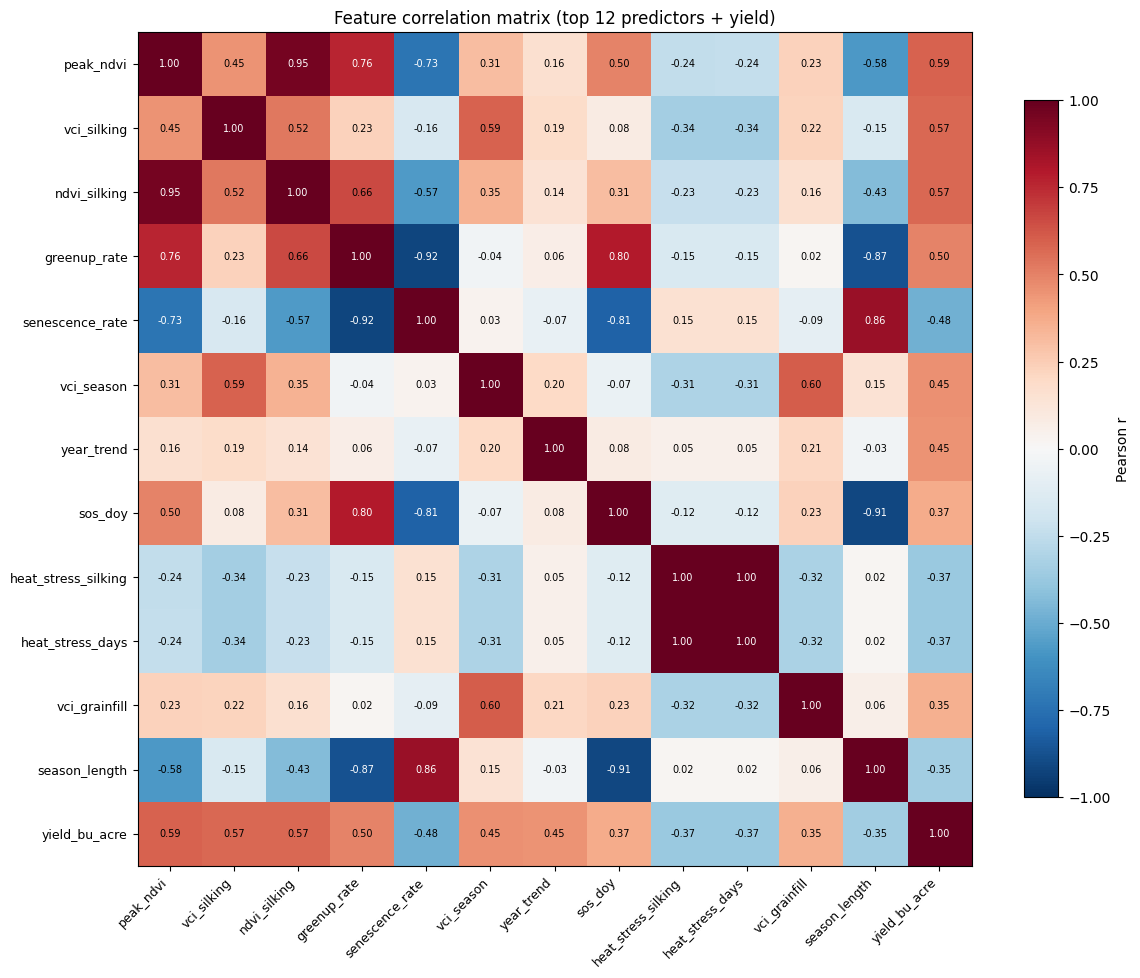

Saved: data/interim/feature_correlation_matrix.png


In [15]:
top_feats   = corr.head(12).index.tolist() + ['yield_bu_acre']
corr_matrix = train_df[top_feats].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.8, label='Pearson r')
ax.set_xticks(range(len(top_feats)))
ax.set_yticks(range(len(top_feats)))
ax.set_xticklabels(top_feats, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(top_feats, fontsize=9)
for i in range(len(top_feats)):
    for j in range(len(top_feats)):
        v = corr_matrix.iloc[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                fontsize=7, color='black' if abs(v) < 0.7 else 'white')
ax.set_title('Feature correlation matrix (top 12 predictors + yield)', fontsize=12)
plt.tight_layout()
plt.savefig(DATA_INTERIM / 'feature_correlation_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: data/interim/feature_correlation_matrix.png')

In [16]:
print('=' * 55)
print('  MODULE 2 COMPLETE')
print('=' * 55)
groups = {
    'Phenology (NDVI)' : [c for c in FEATURE_COLS if any(x in c for x in ['sos','eos','peak','integrated','greenup','senescence','ndvi_','season_length','vci'])],
    'Weather stress'   : [c for c in FEATURE_COLS if any(x in c for x in ['gdd','heat','spi','vpd','precip'])],
    'Water balance'    : [c for c in FEATURE_COLS if any(x in c for x in ['pet','aet','water_stress','deficit','drought','field_capacity'])],
    'Soil (static)'    : [c for c in FEATURE_COLS if any(x in c for x in ['sand','clay','om_','awc','ph','cec'])],
    'Temporal trend'   : ['year_trend'],
}
total = 0
for g, feats in groups.items():
    n = len([f for f in feats if f in FEATURE_COLS])
    print(f'  {g:<30} {n:>3} features')
    total += n
print(f'  {"Total":<30} {total:>3} features')
print(f'  County-years : {len(feature_matrix):,}')
print(f'  Train/Val/Test: {len(train_df)}/{len(val_df)}/{len(test_df)}')
print('  -> Next: Module 3 - modeling.ipynb')

  MODULE 2 COMPLETE
  Phenology (NDVI)                15 features
  Weather stress                  11 features
  Water balance                    7 features
  Soil (static)                    6 features
  Temporal trend                   1 features
  Total                           40 features
  County-years : 6,620
  Train/Val/Test: 6096/272/252
  -> Next: Module 3 - modeling.ipynb
